## 1. Dataset path

In [41]:
from pathlib import Path

DATASET_DIR = Path(r"D:/проекты/PowerGridReconfig/data/gridfm_generated/case118_bootstrap_v1")


## 2. Imports and dataset discovery

In [42]:
import json
import math
import gc
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

dataset_dir = DATASET_DIR.resolve()
raw_dir = dataset_dir / "raw" if (dataset_dir / "raw").exists() else dataset_dir

bus_path = raw_dir / "bus_data.parquet"
branch_path = raw_dir / "branch_data.parquet"
gen_path = raw_dir / "gen_data.parquet"
runtime_path = raw_dir / "runtime_data.parquet"
ybus_path = raw_dir / "y_bus_data.parquet"

transition_candidates = [
    dataset_dir / "transitions" / "transitions_balanced.csv",
    dataset_dir / "transitions_balanced.csv",
]
transitions_path = next((p for p in transition_candidates if p.exists()), None)

config_candidates = sorted((dataset_dir / "configs").glob("*.yaml")) if (dataset_dir / "configs").exists() else []
config_path = config_candidates[0] if config_candidates else None

required = [bus_path, branch_path, gen_path]
missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

print(f"Dataset: {dataset_dir}")
print(f"Raw data: {raw_dir}")
print(f"Transitions: {transitions_path if transitions_path else 'not found'}")
print(f"Config: {config_path if config_path else 'not found'}")


Dataset: D:\проекты\PowerGridReconfig\data\gridfm_generated\case118_bootstrap_v1
Raw data: D:\проекты\PowerGridReconfig\data\gridfm_generated\case118_bootstrap_v1\raw
Transitions: D:\проекты\PowerGridReconfig\data\gridfm_generated\case118_bootstrap_v1\transitions\transitions_balanced.csv
Config: D:\проекты\PowerGridReconfig\data\gridfm_generated\case118_bootstrap_v1\configs\chunk00.yaml


In [3]:
import matplotlib.pyplot as plt

FIG_W = 10
FIG_H = 5.5

plt.rcParams["figure.figsize"] = (FIG_W, FIG_H)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 3. Dataset overview

In [4]:
import pyarrow.parquet as pq

overview_rows = []

for name, path in [
    ("bus_data", bus_path),
    ("branch_data", branch_path),
    ("gen_data", gen_path),
    ("runtime_data", runtime_path),
    ("y_bus_data", ybus_path),
]:
    if path.exists():
        metadata = pq.ParquetFile(path)
        overview_rows.append({
            "Dataset": name,
            "Rows": metadata.metadata.num_rows,
            "Columns": len(metadata.schema.names),
            "File": path.name,
        })

overview = pd.DataFrame(overview_rows)
display(overview)


,Dataset,Rows,Columns,File
0,bus_data,1416000,18,bus_data.parquet
1,branch_data,2232000,27,branch_data.parquet
2,gen_data,648000,16,gen_data.parquet
3,runtime_data,12000,4,runtime_data.parquet
4,y_bus_data,5688556,7,y_bus_data.parquet


## 4. Load diversity

In [5]:
bus = pd.read_parquet(
    bus_path,
    columns=["scenario", "load_scenario_idx", "bus", "Pd", "Qd", "Pg", "Qg", "Vm", "Va"]
)

bus["scenario"] = bus["scenario"].astype(int)

scenario_bus = (
    bus.groupby("scenario", sort=True)
    .agg(
        load_scenario_idx=("load_scenario_idx", "first"),
        total_load_p_mw=("Pd", "sum"),
        total_load_q_mvar=("Qd", "sum"),
        total_bus_pg_mw=("Pg", "sum"),
        total_bus_qg_mvar=("Qg", "sum"),
        min_voltage_pu=("Vm", "min"),
        max_voltage_pu=("Vm", "max"),
        mean_voltage_pu=("Vm", "mean"),
        voltage_std_pu=("Vm", "std"),
    )
    .reset_index()
)

load_stats = scenario_bus[
    ["total_load_p_mw", "total_load_q_mvar"]
].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

display(load_stats)


,count,mean,std,min,5%,25%,50%,75%,95%,max
total_load_p_mw,12000.0,3739.541221,347.636378,2764.491760,3185.487572,3485.405768,3747.562496,3958.772138,4351.746378,4823.536866
total_load_q_mvar,12000.0,1267.239910,117.783313,953.479483,1079.596402,1182.760586,1270.087071,1340.939669,1476.588835,1649.644500


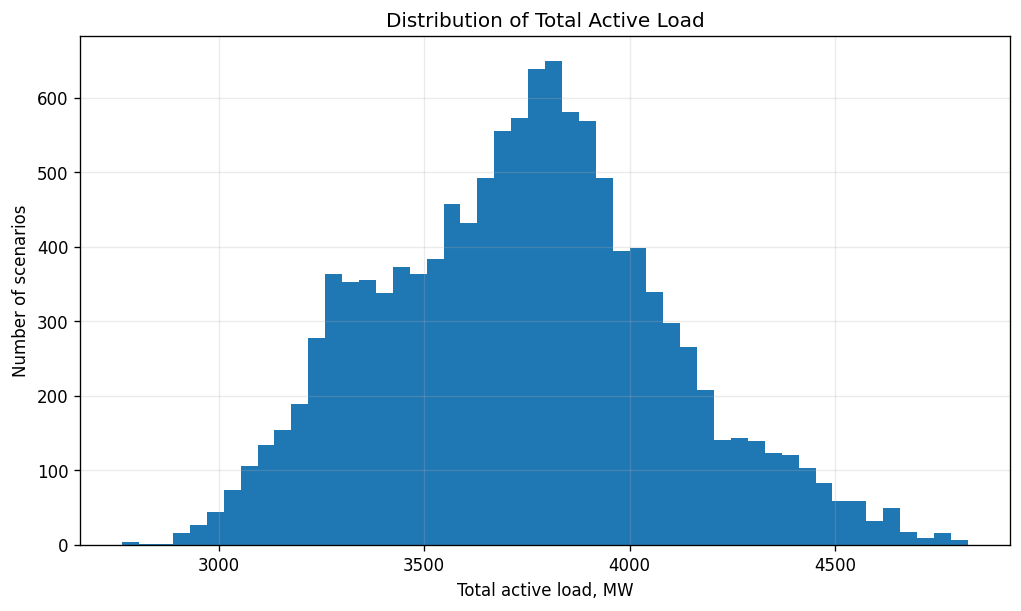

In [6]:
fig, ax = plt.subplots()
ax.hist(scenario_bus["total_load_p_mw"], bins=50)
ax.set_title("Distribution of Total Active Load")
ax.set_xlabel("Total active load, MW")
ax.set_ylabel("Number of scenarios")
plt.show()


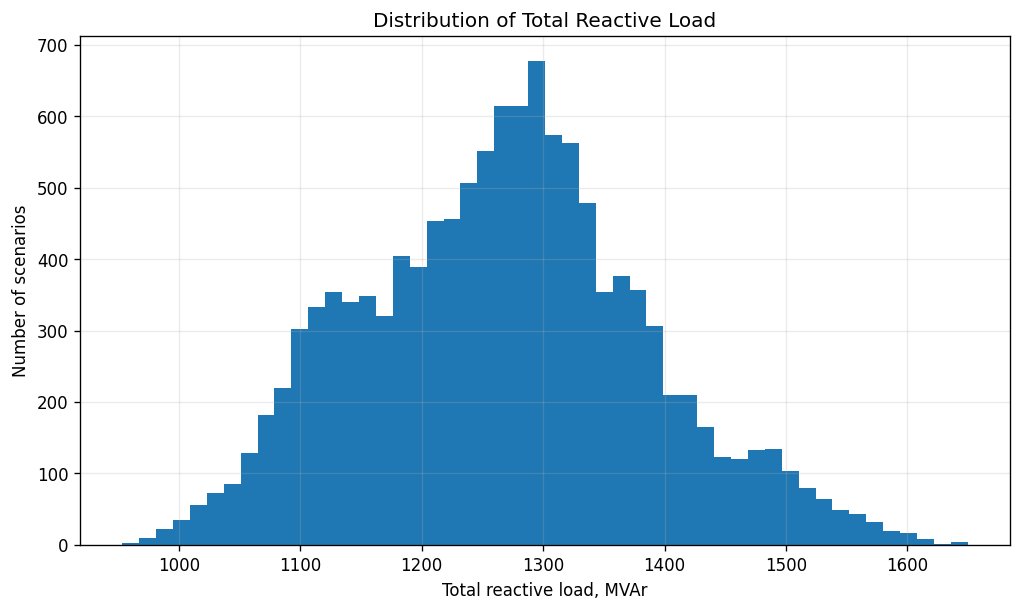

In [7]:
fig, ax = plt.subplots()
ax.hist(scenario_bus["total_load_q_mvar"], bins=50)
ax.set_title("Distribution of Total Reactive Load")
ax.set_xlabel("Total reactive load, MVAr")
ax.set_ylabel("Number of scenarios")
plt.show()


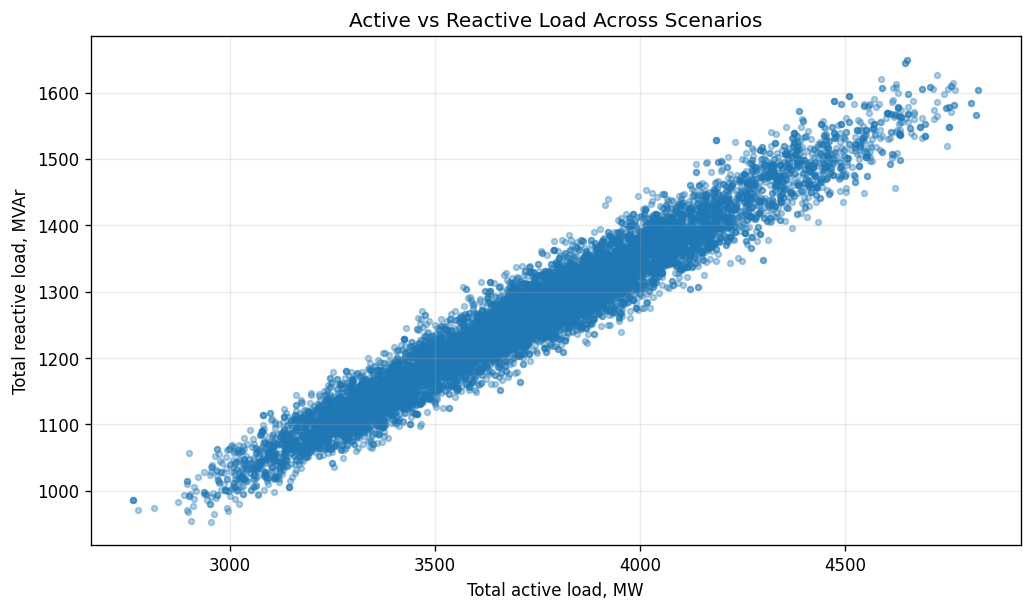

In [8]:
fig, ax = plt.subplots()
ax.scatter(
    scenario_bus["total_load_p_mw"],
    scenario_bus["total_load_q_mvar"],
    s=12,
    alpha=0.35,
)
ax.set_title("Active vs Reactive Load Across Scenarios")
ax.set_xlabel("Total active load, MW")
ax.set_ylabel("Total reactive load, MVAr")
plt.show()


## 5. Bus-level load variation

In [9]:
load_by_bus = (
    bus.groupby("bus", sort=True)
    .agg(
        mean_p_mw=("Pd", "mean"),
        std_p_mw=("Pd", "std"),
        min_p_mw=("Pd", "min"),
        max_p_mw=("Pd", "max"),
        mean_q_mvar=("Qd", "mean"),
        std_q_mvar=("Qd", "std"),
        min_q_mvar=("Qd", "min"),
        max_q_mvar=("Qd", "max"),
    )
    .reset_index()
)

load_by_bus["p_range_mw"] = load_by_bus["max_p_mw"] - load_by_bus["min_p_mw"]
load_by_bus["q_range_mvar"] = load_by_bus["max_q_mvar"] - load_by_bus["min_q_mvar"]

top_variable_loads = load_by_bus.sort_values("p_range_mw", ascending=False).head(15)
display(top_variable_loads)


,bus,mean_p_mw,std_p_mw,min_p_mw,max_p_mw,mean_q_mvar,std_q_mvar,min_q_mvar,max_q_mvar,p_range_mw,q_range_mvar
58,58,244.254136,36.080996,157.105642,364.124286,99.503140,14.647726,64.677364,147.510018,207.018644,82.832654
115,115,162.338483,23.956080,103.184803,241.457326,0.000000,0.000000,0.000000,0.000000,138.272523,0.000000
89,89,144.052883,21.060054,90.543834,216.055897,36.985698,5.542993,23.391496,55.357889,125.512064,31.966393
79,79,114.527519,16.861200,71.463368,170.277802,22.888492,3.400450,14.458253,34.046052,98.814434,19.587798
53,53,99.416542,14.709806,63.546601,149.525592,28.209718,4.151459,17.764878,42.397607,85.978991,24.632729
41,41,84.773317,12.612316,53.772708,126.411327,20.285799,2.959319,12.937981,30.175630,72.638620,17.237649
14,14,79.611529,11.866966,50.750644,118.160865,26.491446,3.967571,16.923401,39.736044,67.410221,22.812643
48,48,76.675865,11.462070,48.834532,113.708306,26.456026,3.887889,16.500316,39.387384,64.873774,22.887068
55,55,73.914074,10.948196,46.668593,110.279447,15.854782,2.352458,10.169572,23.699076,63.610854,13.529505
61,61,67.800433,9.913644,42.481942,100.827174,12.316409,1.815091,7.829708,18.127068,58.345232,10.297360


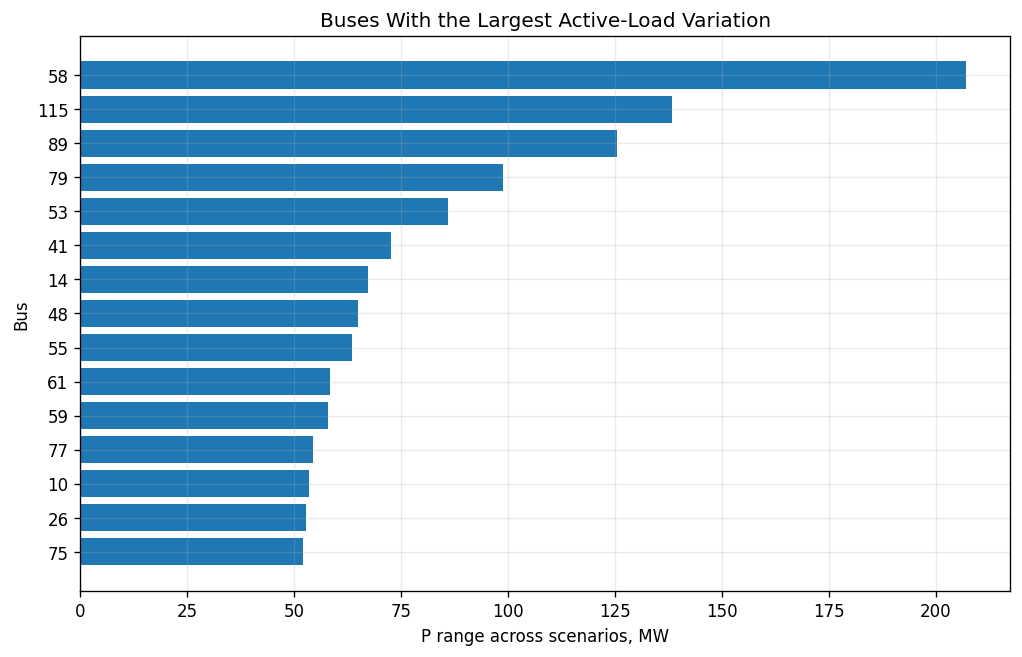

In [10]:
plot_data = top_variable_loads.sort_values("p_range_mw")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["bus"].astype(str), plot_data["p_range_mw"])
ax.set_title("Buses With the Largest Active-Load Variation")
ax.set_xlabel("P range across scenarios, MW")
ax.set_ylabel("Bus")
plt.show()


## 6. Generation diversity

In [11]:
gen = pd.read_parquet(
    gen_path,
    columns=[
        "scenario",
        "idx",
        "bus",
        "p_mw",
        "q_mvar",
        "min_p_mw",
        "max_p_mw",
        "min_q_mvar",
        "max_q_mvar",
        "cp0_eur",
        "cp1_eur_per_mw",
        "cp2_eur_per_mw2",
        "in_service",
        "is_slack_gen",
    ],
)

gen["scenario"] = gen["scenario"].astype(int)

scenario_gen = (
    gen.groupby("scenario", sort=True)
    .agg(
        total_generation_p_mw=("p_mw", "sum"),
        total_generation_q_mvar=("q_mvar", "sum"),
        active_generators=("in_service", "sum"),
    )
    .reset_index()
)

generation_stats = scenario_gen[
    ["total_generation_p_mw", "total_generation_q_mvar"]
].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

display(generation_stats)


,count,mean,std,min,5%,25%,50%,75%,95%,max
total_generation_p_mw,12000.0,3882.228424,364.101773,2855.481694,3300.326179,3616.828720,3890.531651,4110.711252,4530.765399,5040.945631
total_generation_q_mvar,12000.0,632.560664,260.948443,-110.416647,233.878752,454.332009,611.791631,787.020181,1100.389163,1733.288835


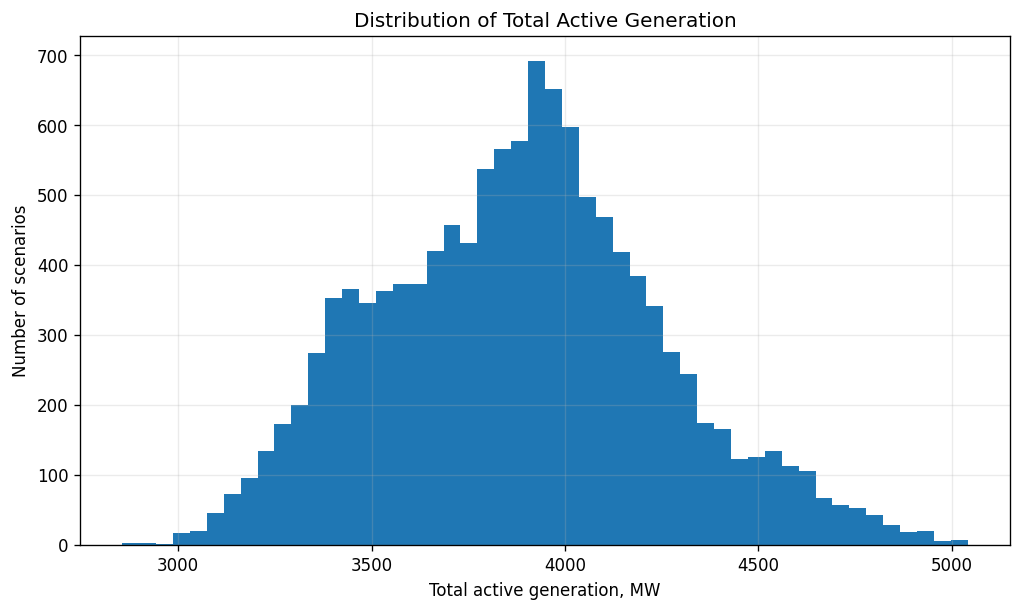

In [12]:
fig, ax = plt.subplots()
ax.hist(scenario_gen["total_generation_p_mw"], bins=50)
ax.set_title("Distribution of Total Active Generation")
ax.set_xlabel("Total active generation, MW")
ax.set_ylabel("Number of scenarios")
plt.show()


In [13]:
gen_variation = (
    gen.groupby(["idx", "bus"], sort=True)
    .agg(
        mean_p_mw=("p_mw", "mean"),
        std_p_mw=("p_mw", "std"),
        min_p_mw=("p_mw", "min"),
        max_p_mw=("p_mw", "max"),
        mean_q_mvar=("q_mvar", "mean"),
        std_q_mvar=("q_mvar", "std"),
        min_q_mvar=("q_mvar", "min"),
        max_q_mvar=("q_mvar", "max"),
    )
    .reset_index()
)

gen_variation["p_range_mw"] = gen_variation["max_p_mw"] - gen_variation["min_p_mw"]
gen_variation["q_range_mvar"] = gen_variation["max_q_mvar"] - gen_variation["min_q_mvar"]

top_variable_generators = gen_variation.sort_values("p_range_mw", ascending=False).head(15)
display(top_variable_generators)


,idx,bus,mean_p_mw,std_p_mw,min_p_mw,max_p_mw,mean_q_mvar,std_q_mvar,min_q_mvar,max_q_mvar,p_range_mw,q_range_mvar
29,29.0,68,671.517333,339.815634,2.381226e-01,1257.716624,-142.383240,66.167067,-312.159303,54.224199,1257.478502,366.383502
28,28.0,65,19.446823,76.883281,-3.408021e-07,783.999995,-60.530446,29.628944,-79.386907,194.383202,783.999996,273.770109
39,39.0,88,410.218764,144.737311,5.826796e-06,637.000005,-11.304829,20.631025,-57.903237,66.943229,636.999999,124.846466
36,36.0,79,379.798958,195.642588,9.256474e-07,509.000004,3.830364,47.214479,-143.881321,183.794843,509.000003,327.676163
4,4.0,9,449.576715,101.432684,8.706942e-06,505.000004,-92.667573,17.171976,-146.999277,-73.813230,504.999996,73.186047
11,11.0,25,481.622882,24.037009,1.476018e-05,485.000004,8.733422,22.775039,-43.271967,88.587051,484.999989,131.859019
27,27.0,64,2.057011,23.659318,-4.706503e-07,440.999994,12.128992,83.655399,-193.553250,238.015530,440.999995,431.568779
24,24.0,58,275.563968,78.802073,1.068390e-06,308.000003,80.297925,25.601174,16.083383,169.459915,308.000001,153.376532
10,10.0,24,41.071960,66.554336,-1.164324e-07,220.999984,-37.785240,18.219258,-50.261750,38.954385,220.999984,89.216135
45,45.0,102,11.391765,17.010653,-5.808217e-07,107.999998,12.583625,12.096509,-14.999906,50.121245,107.999999,65.121151


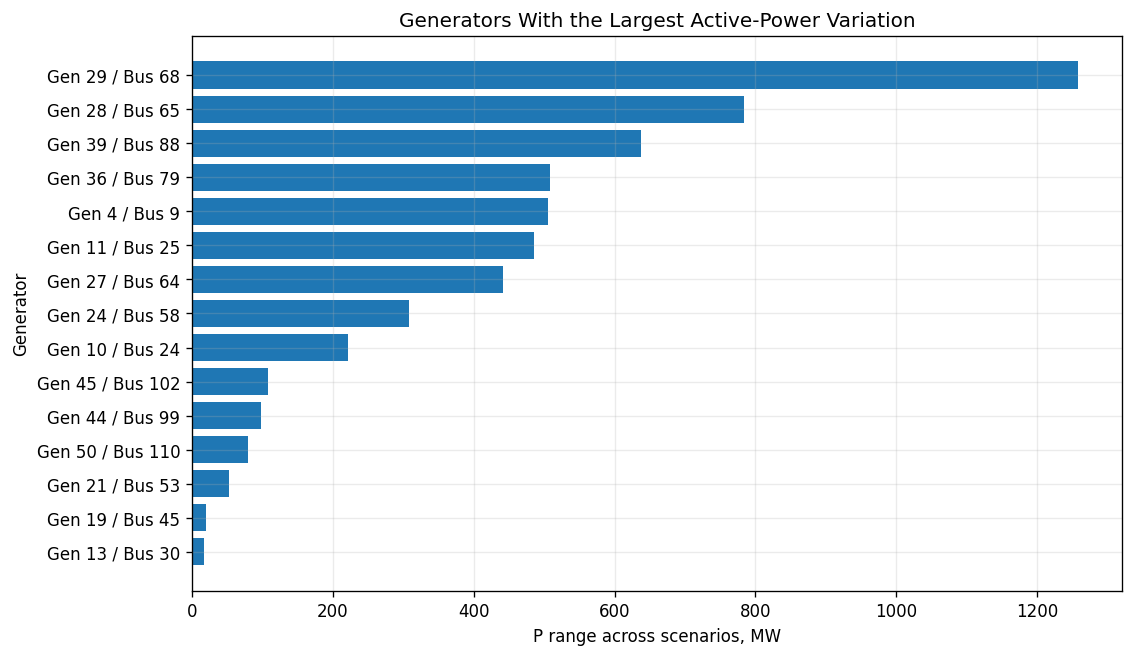

In [14]:
plot_data = top_variable_generators.sort_values("p_range_mw").copy()
plot_data["label"] = "Gen " + plot_data["idx"].astype(int).astype(str) + " / Bus " + plot_data["bus"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["label"], plot_data["p_range_mw"])
ax.set_title("Generators With the Largest Active-Power Variation")
ax.set_xlabel("P range across scenarios, MW")
ax.set_ylabel("Generator")
plt.show()


## 7. Generator cost perturbation

In [15]:
cost_variation = (
    gen.groupby(["idx", "bus"], sort=True)
    .agg(
        cp1_min=("cp1_eur_per_mw", "min"),
        cp1_max=("cp1_eur_per_mw", "max"),
        cp1_mean=("cp1_eur_per_mw", "mean"),
        cp2_min=("cp2_eur_per_mw2", "min"),
        cp2_max=("cp2_eur_per_mw2", "max"),
        cp2_mean=("cp2_eur_per_mw2", "mean"),
    )
    .reset_index()
)

cost_variation["cp1_range"] = cost_variation["cp1_max"] - cost_variation["cp1_min"]
cost_variation["cp2_range"] = cost_variation["cp2_max"] - cost_variation["cp2_min"]

display(cost_variation.sort_values("cp1_range", ascending=False).head(15))


,idx,bus,cp1_min,cp1_max,cp1_mean,cp2_min,cp2_max,cp2_mean,cp1_range,cp2_range
5,5.0,11,105.901487,143.268601,124.444239,0.0,0.0,0.0,37.367113,0.0
50,50.0,110,29.787388,40.299139,35.024632,0.0,0.0,0.0,10.511751,0.0
27,27.0,64,29.564546,39.998171,34.737792,0.0,0.0,0.0,10.433626,0.0
38,38.0,86,28.962643,39.179728,34.049647,0.0,0.0,0.0,10.217085,0.0
28,28.0,65,27.768682,37.567635,32.672554,0.0,0.0,0.0,9.798953,0.0
10,10.0,24,24.606388,33.289038,28.837013,0.0,0.0,0.0,8.682650,0.0
45,45.0,102,24.352163,32.945570,28.651705,0.0,0.0,0.0,8.593407,0.0
21,21.0,53,23.186114,31.368307,27.314721,0.0,0.0,0.0,8.182193,0.0
13,13.0,30,22.095644,29.891534,25.997941,0.0,0.0,0.0,7.795890,0.0
29,29.0,68,21.898193,29.621152,25.862077,0.0,0.0,0.0,7.722959,0.0


## 8. Topology diversity

In [16]:
branch = pd.read_parquet(
    branch_path,
    columns=[
        "scenario",
        "idx",
        "from_bus",
        "to_bus",
        "pf",
        "qf",
        "pt",
        "qt",
        "r",
        "x",
        "b",
        "rate_a",
        "br_status",
    ],
)

branch["scenario"] = branch["scenario"].astype(int)
branch["idx"] = branch["idx"].astype(int)

outaged = branch[branch["br_status"] <= 0].copy()

outage_counts = (
    outaged.groupby(["idx", "from_bus", "to_bus"], sort=False)
    .size()
    .rename("outage_count")
    .reset_index()
    .sort_values("outage_count", ascending=False)
)

topology_summary = pd.DataFrame({
    "Metric": [
        "Scenarios",
        "Unique outaged branches",
        "Minimum outages per scenario",
        "Maximum outages per scenario",
    ],
    "Value": [
        branch["scenario"].nunique(),
        outaged["idx"].nunique(),
        outaged.groupby("scenario").size().min(),
        outaged.groupby("scenario").size().max(),
    ],
})

display(topology_summary)
display(outage_counts.head(20))


,Metric,Value
0,Scenarios,12000
1,Unique outaged branches,60
2,Minimum outages per scenario,1
3,Maximum outages per scenario,1


,idx,from_bus,to_bus,outage_count
42,31,25,24,1032
43,7,7,4,999
57,37,25,29,994
0,163,99,103,746
1,106,67,68,700
20,158,98,99,656
50,125,67,80,655
36,126,80,79,650
5,166,99,105,547
6,157,97,99,519


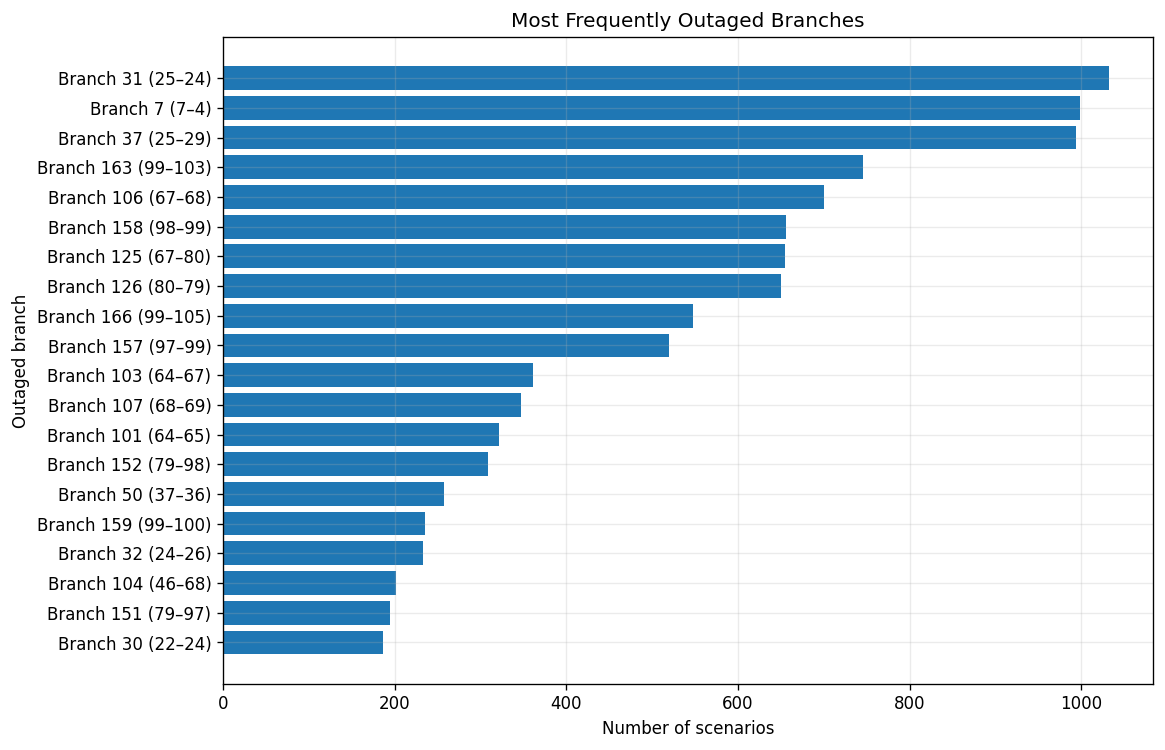

In [17]:
plot_data = outage_counts.head(20).sort_values("outage_count")
plot_labels = (
    "Branch "
    + plot_data["idx"].astype(str)
    + " ("
    + plot_data["from_bus"].astype(str)
    + "–"
    + plot_data["to_bus"].astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_labels, plot_data["outage_count"])
ax.set_title("Most Frequently Outaged Branches")
ax.set_xlabel("Number of scenarios")
ax.set_ylabel("Outaged branch")
plt.show()


## 9. Branch parameter diversity

In [18]:
branch_reference = (
    branch.groupby("idx", sort=True)
    .agg(
        r_reference=("r", "median"),
        x_reference=("x", "median"),
    )
    .reset_index()
)

branch_parameters = branch[["scenario", "idx", "r", "x"]].merge(
    branch_reference,
    on="idx",
    how="left",
)

r_ok = branch_parameters["r_reference"].abs() > 1e-12
x_ok = branch_parameters["x_reference"].abs() > 1e-12

branch_parameters.loc[r_ok, "r_deviation_percent"] = (
    branch_parameters.loc[r_ok, "r"] / branch_parameters.loc[r_ok, "r_reference"] - 1.0
) * 100.0

branch_parameters.loc[x_ok, "x_deviation_percent"] = (
    branch_parameters.loc[x_ok, "x"] / branch_parameters.loc[x_ok, "x_reference"] - 1.0
) * 100.0

parameter_stats = branch_parameters[
    ["r_deviation_percent", "x_deviation_percent"]
].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

display(parameter_stats)


,count,mean,std,min,1%,5%,50%,95%,99%,max
r_deviation_percent,2124000.0,-0.000080,1.154818,-2.071019,-1.960272,-1.800649,0.0,1.799923,1.959398,2.051595
x_deviation_percent,2232000.0,0.001024,1.154731,-2.060700,-1.956240,-1.796982,0.0,1.802963,1.963263,2.056847


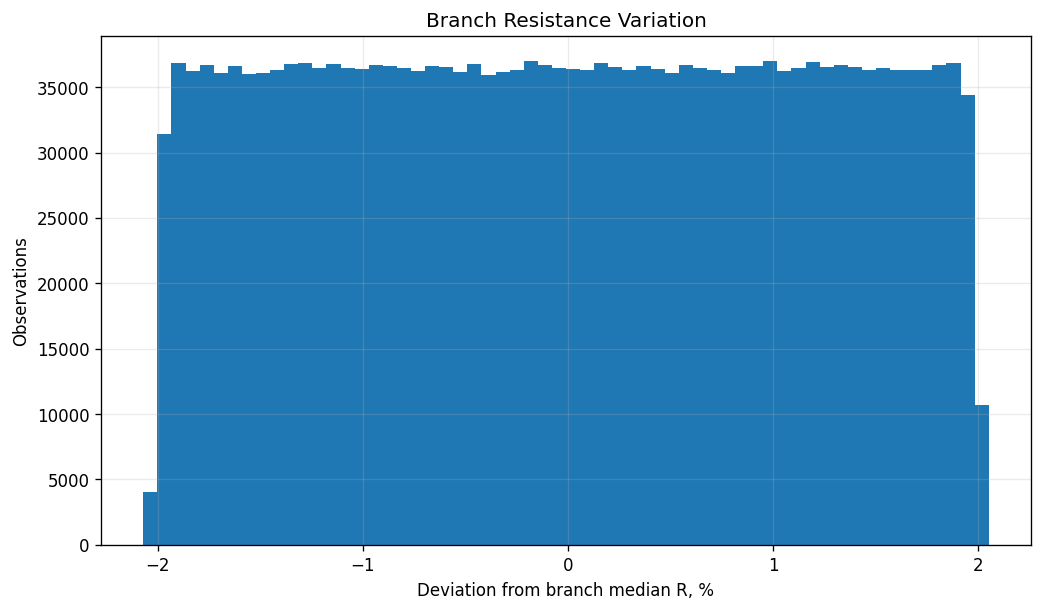

In [19]:
fig, ax = plt.subplots()
ax.hist(branch_parameters["r_deviation_percent"].dropna(), bins=60)
ax.set_title("Branch Resistance Variation")
ax.set_xlabel("Deviation from branch median R, %")
ax.set_ylabel("Observations")
plt.show()


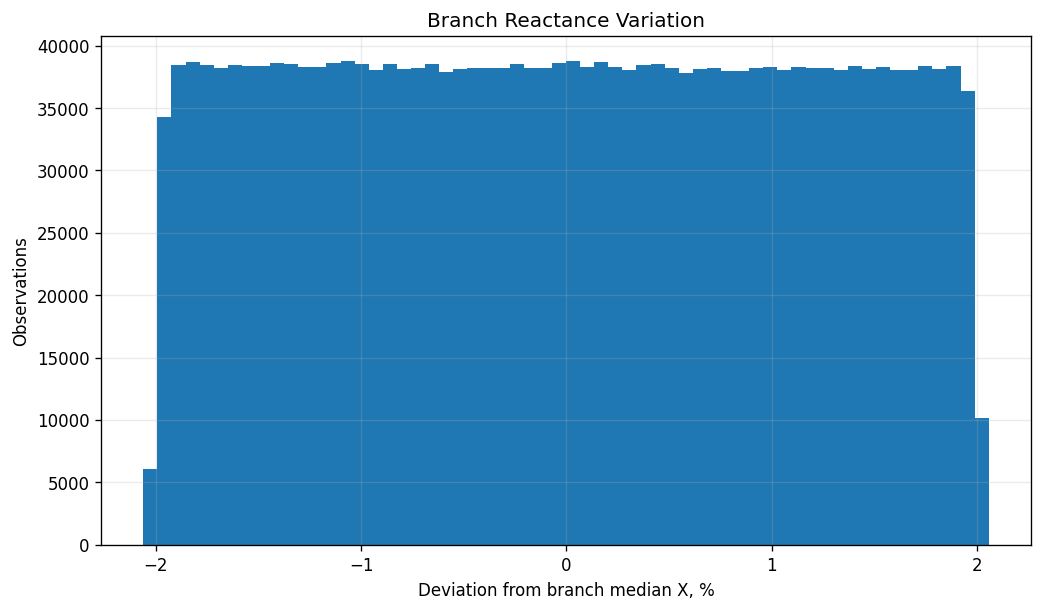

In [20]:
fig, ax = plt.subplots()
ax.hist(branch_parameters["x_deviation_percent"].dropna(), bins=60)
ax.set_title("Branch Reactance Variation")
ax.set_xlabel("Deviation from branch median X, %")
ax.set_ylabel("Observations")
plt.show()


## 10. Branch-flow and loading diversity

In [21]:
s_from = np.sqrt(branch["pf"].to_numpy() ** 2 + branch["qf"].to_numpy() ** 2)
s_to = np.sqrt(branch["pt"].to_numpy() ** 2 + branch["qt"].to_numpy() ** 2)
s_max = np.maximum(s_from, s_to)

rate = branch["rate_a"].replace(0.0, np.nan).to_numpy()
loading = 100.0 * s_max / rate
loading = np.where(branch["br_status"].to_numpy() > 0, loading, 0.0)
loading = np.nan_to_num(loading, nan=0.0, posinf=0.0, neginf=0.0)

branch["loading_percent"] = loading

scenario_branch = (
    branch.groupby("scenario", sort=True)
    .agg(
        max_loading_percent=("loading_percent", "max"),
        mean_loading_percent=("loading_percent", "mean"),
        overloaded_branches=("loading_percent", lambda s: int((s > 100.0).sum())),
        hard_overloaded_branches=("loading_percent", lambda s: int((s > 120.0).sum())),
    )
    .reset_index()
)

display(
    scenario_branch[
        ["max_loading_percent", "overloaded_branches", "hard_overloaded_branches"]
    ].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
)


,count,mean,std,min,5%,25%,50%,75%,95%,max
max_loading_percent,12000.0,142.093850,27.473194,113.045225,115.847172,121.898099,133.36819,149.185608,201.626359,259.606435
overloaded_branches,12000.0,2.716750,1.490762,1.000000,1.000000,2.000000,2.00000,3.000000,5.000000,11.000000
hard_overloaded_branches,12000.0,1.137333,0.917266,0.000000,0.000000,1.000000,1.00000,1.000000,3.000000,6.000000


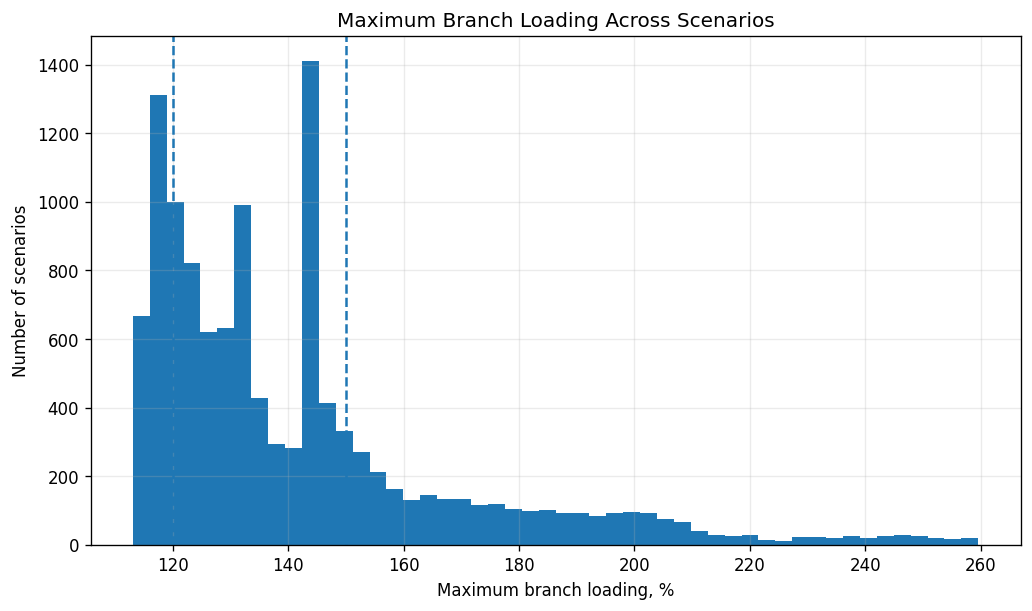

In [22]:
fig, ax = plt.subplots()
ax.hist(scenario_branch["max_loading_percent"], bins=50)
ax.axvline(120.0, linestyle="--")
ax.axvline(150.0, linestyle="--")
ax.set_title("Maximum Branch Loading Across Scenarios")
ax.set_xlabel("Maximum branch loading, %")
ax.set_ylabel("Number of scenarios")
plt.show()


## 11. Voltage diversity

C:\Users\timof\AppData\Local\Temp\ipykernel_3068\120871219.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


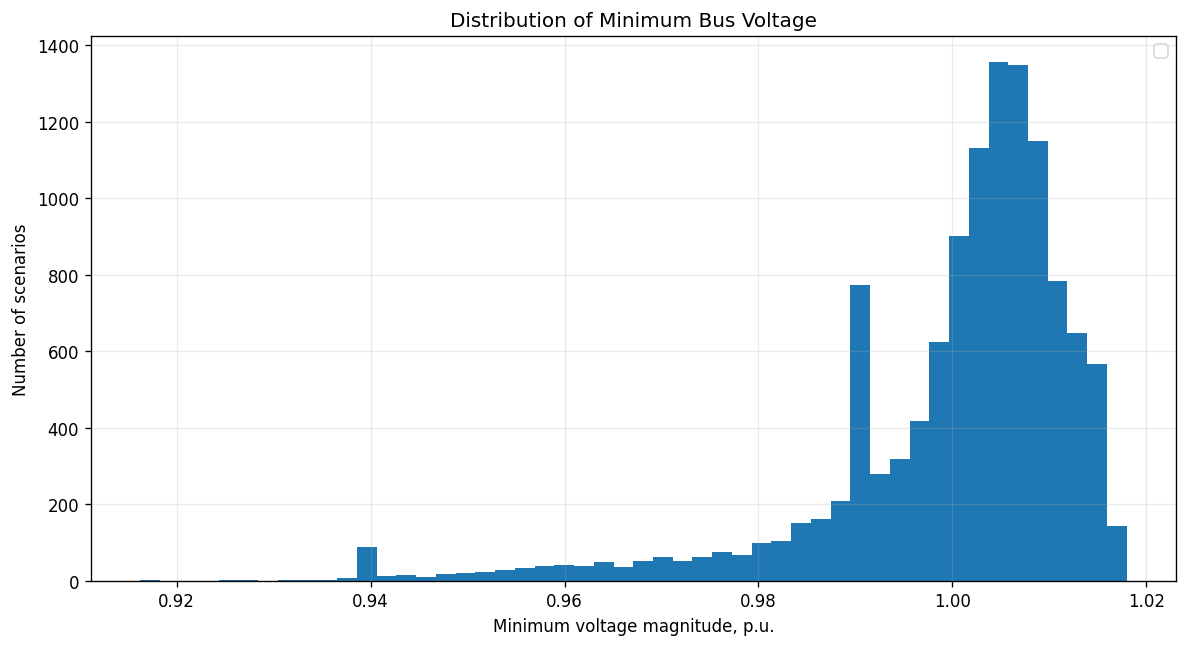

In [23]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(
    scenario_bus["min_voltage_pu"],
    bins=50
)

ax.set_title("Distribution of Minimum Bus Voltage")
ax.set_xlabel("Minimum voltage magnitude, p.u.")
ax.set_ylabel("Number of scenarios")
ax.legend()

plt.tight_layout()
plt.show()

## 12. Scenario comparison table

In [24]:
scenario_outages = (
    outaged.groupby("scenario")["idx"]
    .apply(lambda s: ", ".join(str(int(x)) for x in sorted(s.unique())))
    .rename("outaged_branches")
    .reset_index()
)

scenario_summary = (
    scenario_bus
    .merge(scenario_gen, on="scenario", how="inner")
    .merge(scenario_branch, on="scenario", how="inner")
    .merge(scenario_outages, on="scenario", how="left")
)

scenario_summary["outaged_branches"] = scenario_summary["outaged_branches"].fillna("none")

selected_ids = (
    scenario_summary["total_load_p_mw"]
    .quantile([0.00, 0.20, 0.40, 0.60, 0.80, 1.00])
    .apply(lambda q: (scenario_summary["total_load_p_mw"] - q).abs().idxmin())
    .drop_duplicates()
    .tolist()
)

comparison = scenario_summary.loc[selected_ids, [
    "scenario",
    "total_load_p_mw",
    "total_load_q_mvar",
    "total_generation_p_mw",
    "total_generation_q_mvar",
    "outaged_branches",
    "max_loading_percent",
    "overloaded_branches",
    "hard_overloaded_branches",
    "min_voltage_pu",
    "max_voltage_pu",
]].sort_values("total_load_p_mw")

display(comparison)


,scenario,total_load_p_mw,total_load_q_mvar,total_generation_p_mw,total_generation_q_mvar,outaged_branches,max_loading_percent,overloaded_branches,hard_overloaded_branches,min_voltage_pu,max_voltage_pu
7605,7605,2764.491760,985.919249,2855.481694,101.655836,31,135.863396,3,1,1.011850,1.060000
4065,4065,3419.718071,1166.992284,3522.489247,356.320728,115,123.090513,2,1,1.012801,1.060102
4866,4866,3660.855565,1215.658226,3776.168471,441.522653,166,127.126534,3,1,1.003138,1.060000
299,299,3824.978035,1311.654776,3932.710575,472.434210,159,116.088571,1,0,1.008912,1.060000
9394,9394,4021.029684,1335.840019,4200.887315,949.665065,7,166.474166,4,1,1.001427,1.060000
7497,7497,4823.536866,1603.769236,5017.019345,1327.828203,107,123.964815,4,1,0.945557,1.060003


## 13. Difficulty classes

,difficulty_class,generated,selected,selection_rate_percent
0,simple,13247,2400,18.117310
1,medium,7937,6000,75.595313
2,hard,3637,3600,98.982678


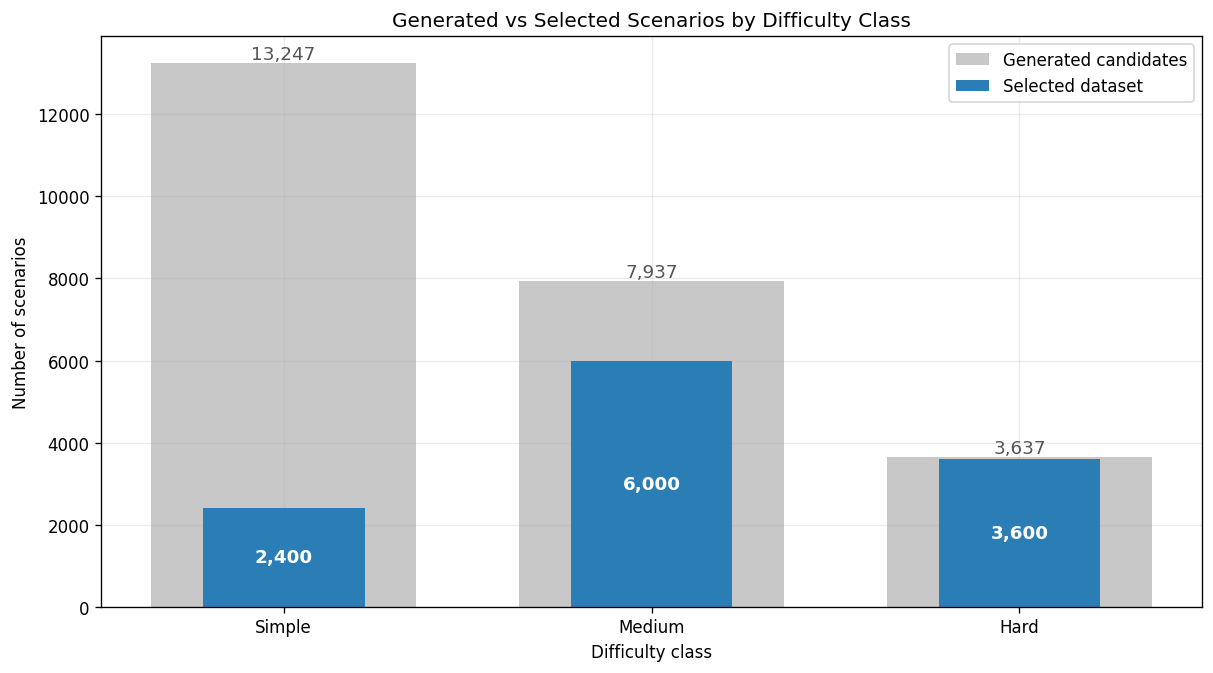

In [43]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

all_candidates_path = next(DATASET_DIR.rglob("all_candidates.csv"), None)

if transitions_path is None:
    raise FileNotFoundError("transitions_balanced.csv was not found.")

if all_candidates_path is None:
    raise FileNotFoundError("all_candidates.csv was not found.")

transitions = pd.read_csv(transitions_path)
all_candidates = pd.read_csv(all_candidates_path)

classes = ["simple", "medium", "hard"]

generated_counts = (
    all_candidates["difficulty_class"]
    .value_counts()
    .reindex(classes, fill_value=0)
)

selected_counts = (
    transitions["difficulty_class"]
    .value_counts()
    .reindex(classes, fill_value=0)
)

difficulty = pd.DataFrame({
    "difficulty_class": classes,
    "generated": generated_counts.values,
    "selected": selected_counts.values,
})

difficulty["selection_rate_percent"] = (
    100.0 * difficulty["selected"] / difficulty["generated"]
)

display(difficulty)

x = np.arange(len(classes))

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)

ax.bar(
    x,
    difficulty["generated"],
    width=0.72,
    color="#c8c8c8",
    label="Generated candidates",
    zorder=1,
)

ax.bar(
    x,
    difficulty["selected"],
    width=0.44,
    color="#2b7db5",
    label="Selected dataset",
    zorder=2,
)

for i, row in difficulty.iterrows():
    ax.text(
        i,
        row["generated"],
        f'{int(row["generated"]):,}',
        ha="center",
        va="bottom",
        fontsize=11,
        color="#555555",
    )

    ax.text(
        i,
        row["selected"] / 2,
        f'{int(row["selected"]):,}',
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )

ax.set_xticks(x)
ax.set_xticklabels(["Simple", "Medium", "Hard"])

ax.set_title("Generated vs Selected Scenarios by Difficulty Class")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Number of scenarios")

ax.legend()

plt.show()


## 14. Combined scenario diversity

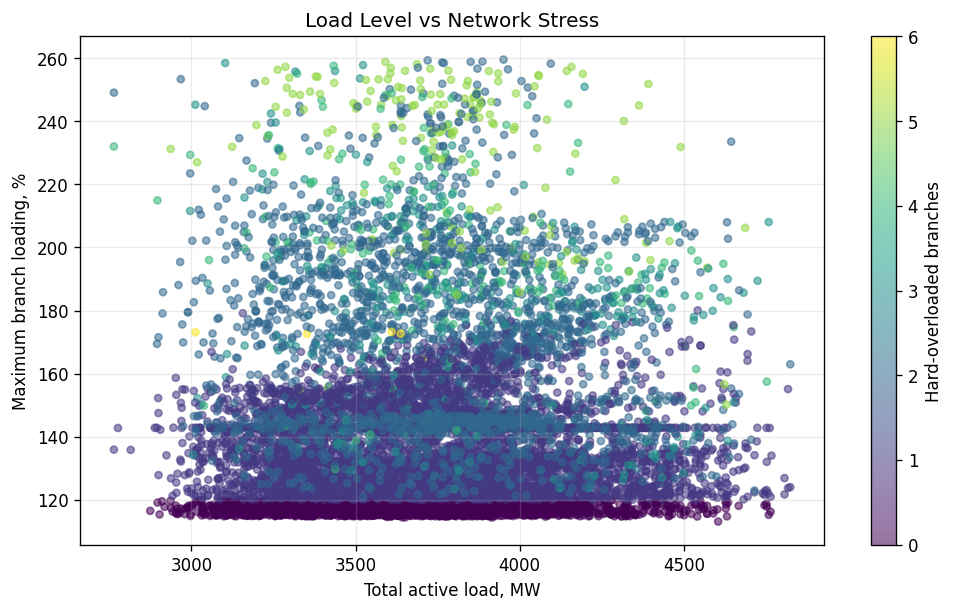

In [26]:
fig, ax = plt.subplots()
scatter = ax.scatter(
    scenario_summary["total_load_p_mw"],
    scenario_summary["max_loading_percent"],
    c=scenario_summary["hard_overloaded_branches"],
    s=18,
    alpha=0.55,
)
ax.set_title("Load Level vs Network Stress")
ax.set_xlabel("Total active load, MW")
ax.set_ylabel("Maximum branch loading, %")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Hard-overloaded branches")
plt.show()


## 15. Key diversity indicators

In [27]:
key_indicators = pd.DataFrame({
    "Indicator": [
        "Number of scenarios",
        "Active-load minimum, MW",
        "Active-load maximum, MW",
        "Reactive-load minimum, MVAr",
        "Reactive-load maximum, MVAr",
        "Generation minimum, MW",
        "Generation maximum, MW",
        "Unique outaged branches",
        "Maximum branch loading minimum, %",
        "Maximum branch loading maximum, %",
        "Maximum overloaded branches",
        "Maximum hard-overloaded branches",
        "Minimum voltage observed, p.u.",
        "Maximum voltage observed, p.u.",
    ],
    "Value": [
        scenario_summary["scenario"].nunique(),
        scenario_summary["total_load_p_mw"].min(),
        scenario_summary["total_load_p_mw"].max(),
        scenario_summary["total_load_q_mvar"].min(),
        scenario_summary["total_load_q_mvar"].max(),
        scenario_summary["total_generation_p_mw"].min(),
        scenario_summary["total_generation_p_mw"].max(),
        outaged["idx"].nunique(),
        scenario_summary["max_loading_percent"].min(),
        scenario_summary["max_loading_percent"].max(),
        scenario_summary["overloaded_branches"].max(),
        scenario_summary["hard_overloaded_branches"].max(),
        scenario_summary["min_voltage_pu"].min(),
        scenario_summary["max_voltage_pu"].max(),
    ],
})

display(key_indicators)


,Indicator,Value
0,Number of scenarios,12000.000000
1,"Active-load minimum, MW",2764.491760
2,"Active-load maximum, MW",4823.536866
3,"Reactive-load minimum, MVAr",953.479483
4,"Reactive-load maximum, MVAr",1649.644500
5,"Generation minimum, MW",2855.481694
6,"Generation maximum, MW",5040.945631
7,Unique outaged branches,60.000000
8,"Maximum branch loading minimum, %",113.045225
9,"Maximum branch loading maximum, %",259.606435


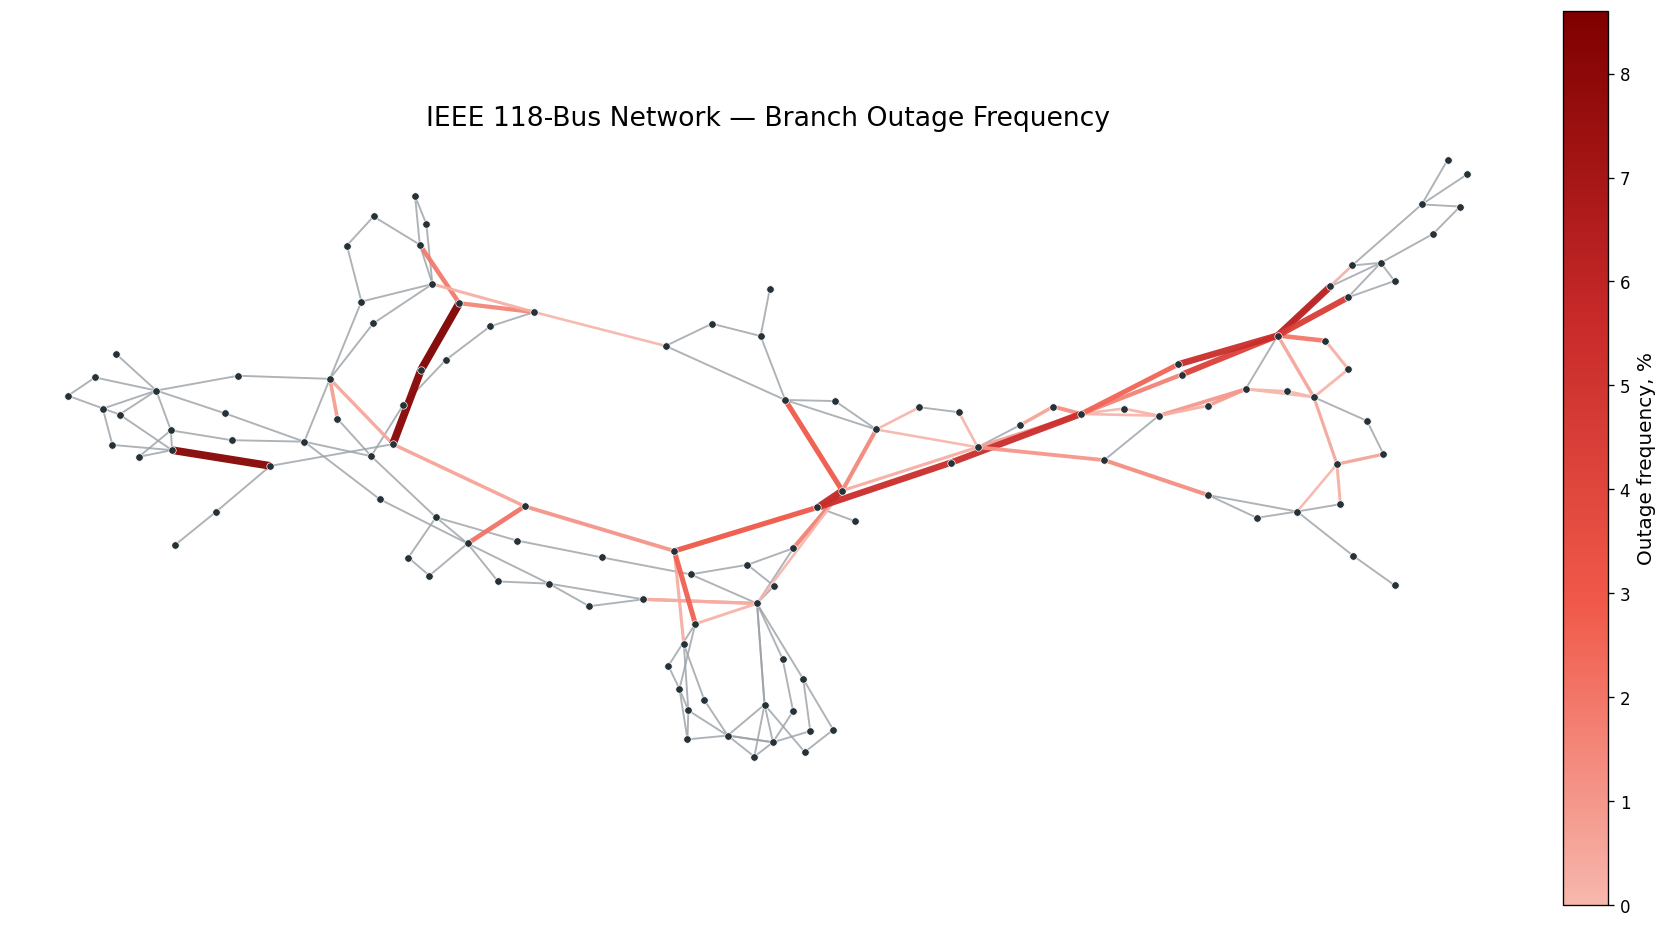

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np

raw_dir = DATASET_DIR / "raw" if (DATASET_DIR / "raw").exists() else DATASET_DIR
branch_path = raw_dir / "branch_data.parquet"

branch_map = pd.read_parquet(
    branch_path,
    columns=["scenario", "idx", "from_bus", "to_bus", "br_status"]
)

branch_map["idx"] = branch_map["idx"].astype(int)
branch_map["from_bus"] = branch_map["from_bus"].astype(int)
branch_map["to_bus"] = branch_map["to_bus"].astype(int)

edge_stats = (
    branch_map
    .assign(outaged=branch_map["br_status"] <= 0)
    .groupby("idx", as_index=False)
    .agg(
        from_bus=("from_bus", "first"),
        to_bus=("to_bus", "first"),
        outage_count=("outaged", "sum"),
        scenario_count=("scenario", "nunique"),
    )
)

edge_stats["outage_frequency"] = (
    100.0 * edge_stats["outage_count"] / edge_stats["scenario_count"]
)

G = nx.Graph()

for row in edge_stats.itertuples():
    G.add_edge(row.from_bus, row.to_bus)

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.42,
    iterations=500,
)

zero_segments = []
outage_segments = []
outage_frequencies = []

for row in edge_stats.itertuples():
    segment = [
        pos[row.from_bus],
        pos[row.to_bus],
    ]

    if row.outage_count == 0:
        zero_segments.append(segment)
    else:
        outage_segments.append(segment)
        outage_frequencies.append(row.outage_frequency)

outage_frequencies = np.asarray(outage_frequencies)

vmax = outage_frequencies.max() if len(outage_frequencies) else 1.0
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)

cmap = LinearSegmentedColormap.from_list(
    "outage_red",
    ["#f7b7ad", "#f05a4a", "#c62828", "#7f0000"]
)

fig, ax = plt.subplots(figsize=(14, 8))

base_edges = LineCollection(
    zero_segments,
    colors="#9aa0a6",
    linewidths=1.15,
    alpha=0.8,
    zorder=1,
)

ax.add_collection(base_edges)

if len(outage_segments):
    widths = 1.5 + 3.2 * np.power(outage_frequencies / vmax, 0.65)

    outage_edges = LineCollection(
        outage_segments,
        cmap=cmap,
        norm=norm,
        linewidths=widths,
        alpha=0.95,
        zorder=2,
    )

    outage_edges.set_array(outage_frequencies)
    ax.add_collection(outage_edges)

nodes = np.array([pos[node] for node in G.nodes()])

ax.scatter(
    nodes[:, 0],
    nodes[:, 1],
    s=20,
    c="#263238",
    edgecolors="white",
    linewidths=0.4,
    zorder=3,
)

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.028,
    pad=0.025,
)

cbar.set_label(
    "Outage frequency, %",
    fontsize=12,
)

ax.set_title(
    "IEEE 118-Bus Network — Branch Outage Frequency",
    fontsize=16,
)

ax.set_aspect("equal")
ax.margins(0.04)
ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
del bus
del gen
del branch
del branch_parameters
gc.collect()


18